In [92]:
"""
2026-06-22 MY

Data: Fortin et al. (2026) mean farm size circa 2000 + calibrated to 2000, 2010, 2020
Modified to match years 1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020
Spatial method: nearest region, country
Temporal method: nearest CALIB year (2000, 2010, 2020)

Note! All regions included and filled. It is expected that agricultural land mask 
is used later to mask out regions were no agricultural land exist (e.g. northern Canada).


Actually Fortin data for CALIB 2020 seems not reliable at least for Finland, Sweden, Slovenia.

"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
import matplotlib.patches as mpatches

import seaborn as sns

import geopandas as gpd
import pandas as pd

from scipy.spatial import cKDTree

from pathlib import Path

In [93]:
fp = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/data/GlobalFarmSize_Dataset_v1.1.0/Output/Dataset/GlobalFarmSizeDataset_Calibrated.shp'
gdf2 = gpd.read_file(fp)

# Exclude Antarctica:
gdf2_filtered = gdf2[gdf2['SUBREG'] != 'Antarctica'].copy()


gdf_proj = gdf2_filtered.to_crs(epsg=3857)          # reproject to metres

gdf_proj['centroid'] = gdf_proj.geometry.centroid

In [94]:
gdf2.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [95]:
gdf_proj.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [100]:
def fill_na_from_nearest(
    gdf,
    cols,
    centroid_col='centroid',
    group_col='NAME_0',
    max_neighbors=8,
    inplace=False
):
    """
    Fill NA values in `cols` from nearest neighbours within the same `group_col`.

    1. Builds a KD-tree from centroid coordinates (centroid_col).
    2. Restricts candidates to the same group_col (e.g. NAME_0, SUBREG).
    3. Only processes rows where FARMSIZE is NA
    4. For each such row, it queries k = max_neighbors + 1 nearest neighbours (the +1 is because the nearest neighbour is often the row itself). For each target column in cols, it scans neighbours in distance order and takes the first non-NA value. It records the neighbour's identifier (NAME_2|NAME_0) in a set for that row. After processing all rows, it writes back the filled values and produces a 'missingInformationFrom' column that contains either NaN (if no fills occurred) or a semicolon-joined string of unique identifiers of neighbours that supplied values.
    5. For each target column in cols, it scans neighbors in distance order and takes the first non-NA value.

    6. Adds/updates 'missingInformationFrom' with donor as "NAME_2|NAME_0".
    """
    gdf_out = gdf if inplace else gdf.copy()
    n = len(gdf_out)

    if group_col not in gdf_out.columns:
        raise ValueError(f"group_col '{group_col}' not found in DataFrame")

    # coords
    coords = np.full((n, 2), np.nan, dtype=float)
    for i, pt in enumerate(gdf_out[centroid_col].values):
        if pt is None:
            continue
        coords[i, 0] = getattr(pt, "x", np.nan)
        coords[i, 1] = getattr(pt, "y", np.nan)

    valid_pos = np.where(~np.isnan(coords).any(axis=1))[0]
    if valid_pos.size <= 1:
        gdf_out['missingInformationFrom'] = pd.NA
        return gdf_out

    # value arrays
    values = {col: gdf_out[col].to_numpy(copy=True) for col in cols}
    #rows_to_check = np.where(np.column_stack([pd.isna(values[c]) for c in cols]).any(axis=1))[0]
    rows_to_check = np.where(pd.isna(values['FARMSIZE']))[0]

    # keep one set per row to avoid duplicate source strings
    if 'missingInformationFrom' in gdf_out.columns:
        def _to_set(x):
            if pd.isna(x) or x == '':
                return set()
            return set(str(x).split(';'))
        missing_from_sets = [_to_set(v) for v in gdf_out['missingInformationFrom'].tolist()]
    else:
        missing_from_sets = [set() for _ in range(n)]

    # group -> valid indices
    group_vals = gdf_out[group_col].to_numpy()
    group_to_indices = {}
    for idx in valid_pos:
        grp = group_vals[idx]
        if pd.isna(grp):
            continue
        group_to_indices.setdefault(grp, []).append(idx)

    # per-group KD-trees
    group_trees = {}
    for grp, idxs in group_to_indices.items():
        idxs_arr = np.array(idxs, dtype=int)
        if idxs_arr.size >= 2:
            group_trees[grp] = (idxs_arr, cKDTree(coords[idxs_arr]))

    for i in rows_to_check:
        grp = group_vals[i]
        if pd.isna(grp) or grp not in group_trees:
            continue
        idxs_arr, tree = group_trees[grp]

        # i must have valid centroid and be in this group index array
        if i not in idxs_arr:
            continue

        k = min(max_neighbors + 1, idxs_arr.size)  # +1 includes self
        dists, neigh_local = tree.query(coords[i], k=k)
        neigh_local = np.atleast_1d(neigh_local)

        for col in cols:
            if not pd.isna(values[col][i]):
                continue
            for local_j in neigh_local:
                orig_idx = int(idxs_arr[int(local_j)])
                if orig_idx == i:
                    continue
                val = values[col][orig_idx]
                if not pd.isna(val):
                    values[col][i] = val
                    name2 = gdf_out.at[orig_idx, 'NAME_2'] if 'NAME_2' in gdf_out.columns else ''
                    name0 = gdf_out.at[orig_idx, 'NAME_0'] if 'NAME_0' in gdf_out.columns else ''
                    missing_from_sets[i].add(f"{name2}|{name0}")
                    break

    # write back
    for col in cols:
        gdf_out[col] = values[col]

    gdf_out['missingInformationFrom'] = [
        pd.NA if len(s) == 0 else ';'.join(sorted(s))
        for s in missing_from_sets
    ]

    return gdf_out

cols_to_fill = ['FARMSIZE', 'CALIB2000', 'CALIB2010', 'CALIB2020']
#gdf_filled = fill_na_from_nearest(gdf_proj, cols_to_fill, centroid_col='centroid', max_neighbors=10, inplace=False)

#print('Number of rows that were filled from neighbours:')
#len(gdf_filled[~gdf_filled['missingInformationFrom'].isna()])  # number of rows that were filled from neighbours


# fill only within same country
gdf_filled_country = fill_na_from_nearest(
    gdf_proj, cols_to_fill, centroid_col='centroid', group_col='NAME_0', max_neighbors=10
)


print('Number of rows that were filled from NAME_0 neighbours:')
print(len(gdf_filled_country[~gdf_filled_country['missingInformationFrom'].isna()]))  # number of rows that were filled from neighbours

print('Number of rows that still need filling from neighbours:')
print(len(gdf_filled_country[gdf_filled_country['FARMSIZE'].isna()]))

#gdf_filled_country[gdf_filled_country['FARMSIZE'].isna()]['NAME_0'].value_counts()

# fill only within same SUBREG
gdf_filled_subreg = fill_na_from_nearest(
    gdf_filled_country, cols_to_fill, centroid_col='centroid', group_col='SUBREG', max_neighbors=10
)


#print('Number of rows still NA after NAME_0 fill:')
before = len(gdf_filled_country[gdf_filled_country['FARMSIZE'].isna()])

# 
print('Cases (head 5) still NA after country fill (no peers found within country):')
print(gdf_filled_country[gdf_filled_country['FARMSIZE'].isna()]['NAME_0'].value_counts().head(5))


#print('Number of rows still NA after SUBREG fill:')
after = len(gdf_filled_subreg[gdf_filled_subreg['FARMSIZE'].isna()])

print('\nNumber of rows that were filled from SUBREG neighbours:')
#print('Rows newly filled by SUBREG:')
print(before - after)

print('Number of rows still NA after SUBREG fill:')
print(after)

print(gdf_filled_subreg[gdf_filled_subreg['FARMSIZE'].isna()]['NAME_0'].value_counts())

# Nigeria:
print('\nNigeria')
gdf_filled_subreg[(gdf_filled_subreg['NAME_0'] == 'Nigeria') & (gdf_filled_subreg['FARMSIZE'].isna())]


# Let's leave as NA (densily populated small region)


Number of rows that were filled from NAME_0 neighbours:
1573
Number of rows that still need filling from neighbours:
80
Cases (head 5) still NA after country fill (no peers found within country):
NAME_0
Nigeria                   19
Canada                     5
Bosnia and Herzegovina     4
Peru                       2
Papua New Guinea           1
Name: count, dtype: int64

Number of rows that were filled from SUBREG neighbours:
76
Number of rows still NA after SUBREG fill:
4
NAME_0
Clipperton Island    1
Sint Maarten         1
Spratly islands      1
Nigeria              1
Name: count, dtype: int64

Nigeria


,ISO3,NAME_0,NAME_1,NAME_2,NAME_3,NAME_4,NAME_DATA,NAME_SHP,REGION,SUBREG,...,YEAR,UNIT,FARMSIZE,CALIB2000,CALIB2010,CALIB2020,DEF,geometry,centroid,missingInformationFrom
18852,NGA,Nigeria,Lagos,Ajeromi/Ifelodun,None,None,None,Ajeromi/Ifelodun,Africa,Sub-Saharan Africa,...,NaN,None,NaN,NaN,NaN,NaN,Not explicit,"POLYGON ((371686.206 722426.411, 371806.209 72...",POINT (370060.561 721344.02),<NA>


In [101]:
print('Number of rows still with FARMSIZE as NA')
len(gdf_filled_subreg[gdf_filled_subreg['FARMSIZE'].isna()])  # number of rows that were filled from neighbours


Number of rows still with FARMSIZE as NA


4

In [151]:
def fill_calib_from_farmsize(
    gdf,
    farmsize_col='FARMSIZE',
    calib_cols=('CALIB2000', 'CALIB2010', 'CALIB2020'),
    missing_info_col='missingInformationFrom',
    tag='FARMSIZE(row)',
    inplace=False
):
    """
    Fill missing CALIB values with the row's FARMSIZE when FARMSIZE is not NA.
    Returns (gdf_out, stats).
    """
    gdf_out = gdf if inplace else gdf.copy()

    # rows eligible for fill: FARMSIZE present AND at least one CALIB missing
    row_mask = gdf_out[farmsize_col].notna() & gdf_out[list(calib_cols)].isna().any(axis=1)

    # fill each CALIB column only where missing on eligible rows
    filled_per_col = {}
    for col in calib_cols:
        m = row_mask & gdf_out[col].isna()
        filled_per_col[col] = int(m.sum())
        gdf_out.loc[m, col] = gdf_out.loc[m, farmsize_col]

    # optional provenance annotation
    if missing_info_col is not None:
        if missing_info_col not in gdf_out.columns:
            gdf_out[missing_info_col] = pd.NA

        touched = row_mask & gdf_out[list(calib_cols)].notna().all(axis=1)
        idxs = gdf_out.index[touched]
        for idx in idxs:
            existing = gdf_out.at[idx, missing_info_col]
            if pd.isna(existing) or existing == '':
                gdf_out.at[idx, missing_info_col] = tag
            else:
                parts = [p for p in str(existing).split(';') if p]
                if tag not in parts:
                    gdf_out.at[idx, missing_info_col] = ';'.join(parts + [tag])

    stats = {
        'rows_with_farmsize_and_any_missing_calib': int(row_mask.sum()),
        'filled_per_col': filled_per_col,
        'rows_still_with_any_missing_calib_given_farmsize': int(
            (gdf_out[farmsize_col].notna() & gdf_out[list(calib_cols)].isna().any(axis=1)).sum()
        )
    }
    return gdf_out, stats

# example
gdf_filled_subreg_expanded, stats_calib_from_farmsize = fill_calib_from_farmsize(gdf_filled_subreg)
stats_calib_from_farmsize

{'rows_with_farmsize_and_any_missing_calib': 4515,
 'filled_per_col': {'CALIB2000': 2328, 'CALIB2010': 2986, 'CALIB2020': 3609},
 'rows_still_with_any_missing_calib_given_farmsize': 0}

In [152]:
# nearest value extrapolation:

#target_years = [1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020]
target_years = range(1992, 2021)

known_years = np.array([2000, 2010, 2020], dtype=float)
known_cols = ['CALIB2000', 'CALIB2010', 'CALIB2020']

def nearest_value_row(row):
    # apply fallbacks
    c2000 = row.get('CALIB2000', np.nan)
    if pd.isna(c2000):
        c2000 = row.get('FARMSIZE', np.nan)
    c2010 = row.get('CALIB2010', np.nan)
    if pd.isna(c2010):
        c2010 = c2000
    c2020 = row.get('CALIB2020', np.nan)
    if pd.isna(c2020):
        c2020 = c2010

    vals = np.array([c2000, c2010, c2020], dtype=float)

    out = []
    for y in target_years:
        order = np.argsort(np.abs(known_years - y))
        chosen = np.nan
        for idx in order:
            v = vals[idx]
            if not np.isnan(v):
                chosen = v
                break
        out.append(chosen)

    return pd.Series({f'EXPO_{y}': out[i] for i, y in enumerate(target_years)})

# apply and join
new_cols = gdf_filled_subreg_expanded.apply(nearest_value_row, axis=1)
gdf_filled_subreg2 = gdf_filled_subreg_expanded.join(new_cols)


In [153]:
print('Number of rows with FARMSIZE as NA')
len(gdf_filled_subreg2[gdf_filled_subreg2['FARMSIZE'].isna()])  # number of rows that were filled from neighbours


Number of rows with FARMSIZE as NA


4

In [154]:
gdf_final = gdf_filled_subreg2.drop(columns = ['centroid'])

In [155]:
gdf_final.crs

<Projected CRS: EPSG:3857>
Name: WGS 84 / Pseudo-Mercator
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: World between 85.06°S and 85.06°N.
- bounds: (-180.0, -85.06, 180.0, 85.06)
Coordinate Operation:
- name: Popular Visualisation Pseudo-Mercator
- method: Popular Visualisation Pseudo Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [156]:
gdf_final4326 = gdf_final.to_crs(epsg=4326)          # reproject to metres
gdf_final4326.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [157]:
gdf_final4326.to_file(filename = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/data/extrapolated_farmSize_by_ADM_from_Fortin2026.gpkg')
#gdf_final.to_file(filename = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/data/extrapolated_farmSize_by_ADM_from_Fortin2026.shp')

In [158]:
# Mean farm size (circa 2000) by subregion:
gdf_subregion_size = gdf_final[['FARMSIZE', 'SUBREG', 'geometry']].groupby(['SUBREG']).mean('FARMSIZE')
gdf_subregion_size

,FARMSIZE
SUBREG,
Australia and New Zealand,12137.445342
Central Asia,1029.436417
Eastern Asia,2.102749
Eastern Europe,23.101767
Latin America and the Caribbean,127.077846
Melanesia,3.488696
Micronesia,1.952162
Northern Africa,8.368046
Northern America,249.210885


In [159]:
# Mean farm size (circa 2000) by subregion:
gdf3 = gdf2_expanded[['FARMSIZE', 'SUBREG', 'geometry']].groupby(['SUBREG']).mean('FARMSIZE')
gdf3

,FARMSIZE
SUBREG,
Antarctica,1474.565217
Australia and New Zealand,10771.517123
Central Asia,1028.693749
Eastern Asia,2.102749
Eastern Europe,23.101767
Latin America and the Caribbean,126.876969
Melanesia,3.385033
Micronesia,4.518309
Northern Africa,8.424521


In [184]:


sns.set_theme(style="whitegrid")


group_col = 'NAME_SHP'
cols_known = ['CALIB2000', 'CALIB2010', 'CALIB2020']
years_known = [2000, 2010, 2020]
cols_ext = ['EXPO_1992','EXPO_1996','EXPO_2000','EXPO_2004','EXPO_2008','EXPO_2012','EXPO_2016','EXPO_2020']
years_ext = [1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020]

#agg = df_fin.groupby(group_col)[cols_known + cols_ext].mean(numeric_only=True)

def plotCountry(country, gdf_final):

    df_fin = gdf_final[gdf_final['NAME_0'] == country].copy()


    palette = sns.color_palette("tab10", n_colors=len(df_fin)) if len(df_fin) <= 10 else sns.color_palette("husl", n_colors=len(df_fin))
    color_map = dict(zip(df_fin[group_col], palette))

    df_fin.set_index('NAME_SHP', inplace=True)


    fig, ax = plt.subplots(figsize=(12, 7))

    for name, row in df_fin.iterrows():
        vals_ext = row[cols_ext].to_numpy(dtype=float)
        vals_known = row[cols_known].to_numpy(dtype=float)
        c = color_map[name]
        ax.plot(years_ext, vals_ext, marker='o', linestyle='-', color=c, alpha=0.9)        # extrapolated (solid)
        ax.plot(years_known, vals_known, marker='s', linestyle='--', color=c, alpha=0.9)   # original (dashed)

    group_handles = [
        Line2D([0], [0], color=color_map.get(name, 'grey'), lw=2, label=name)
        for name in df_fin.index.unique()
    ]

    style_handles = [
        Line2D([0],[0], color='k', linestyle='-', marker='o', label='Extrapolated (1992–2020)'),
        Line2D([0],[0], color='k', linestyle='--', marker='s', label='Original (2000,2010,2020)')
    ]
    leg1 = ax.legend(handles=group_handles, title=group_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, loc='upper right')

    ax.set_xlabel('Year')
    ax.set_ylabel('Farm size (ha)')
    ax.set_title(country + ' — Farm size by subregion')
    ax.grid(True, alpha=0.4)
    fig.tight_layout()


In [193]:
gdf2[gdf2['NAME_0'] == 'Finland'][['CALIB2000', 'CALIB2010', 'CALIB2020']]
gdf2[gdf2['NAME_0'] == 'Sweden'][['CALIB2000', 'CALIB2010', 'CALIB2020']]
gdf2[gdf2['NAME_0'] == 'China'][['CALIB2000', 'CALIB2010', 'CALIB2020']]
gdf2[gdf2['NAME_0'] == 'Australia'][['CALIB2000', 'CALIB2010', 'CALIB2020']]

,CALIB2000,CALIB2010,CALIB2020
21715,NaN,NaN,NaN
21716,292.760434,69.530434,889.514767
21717,NaN,NaN,NaN
21718,NaN,NaN,NaN
21719,1226.984546,1003.754546,1823.738879
...,...,...,...
21772,NaN,NaN,NaN
21773,385.596720,162.366720,982.351053
21774,28858.292103,28635.062103,29455.046436
21775,561.788904,338.558904,1158.543237


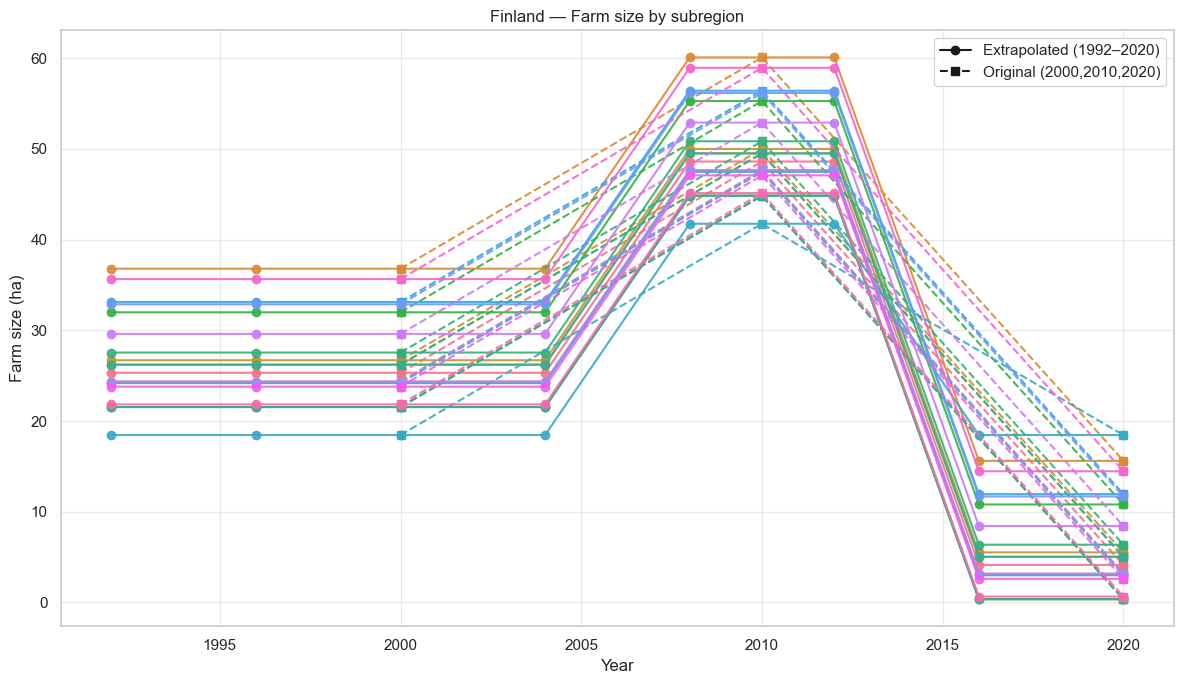

In [185]:
plotCountry('Finland', gdf_final)

### From agricultural statistics (LUKE):

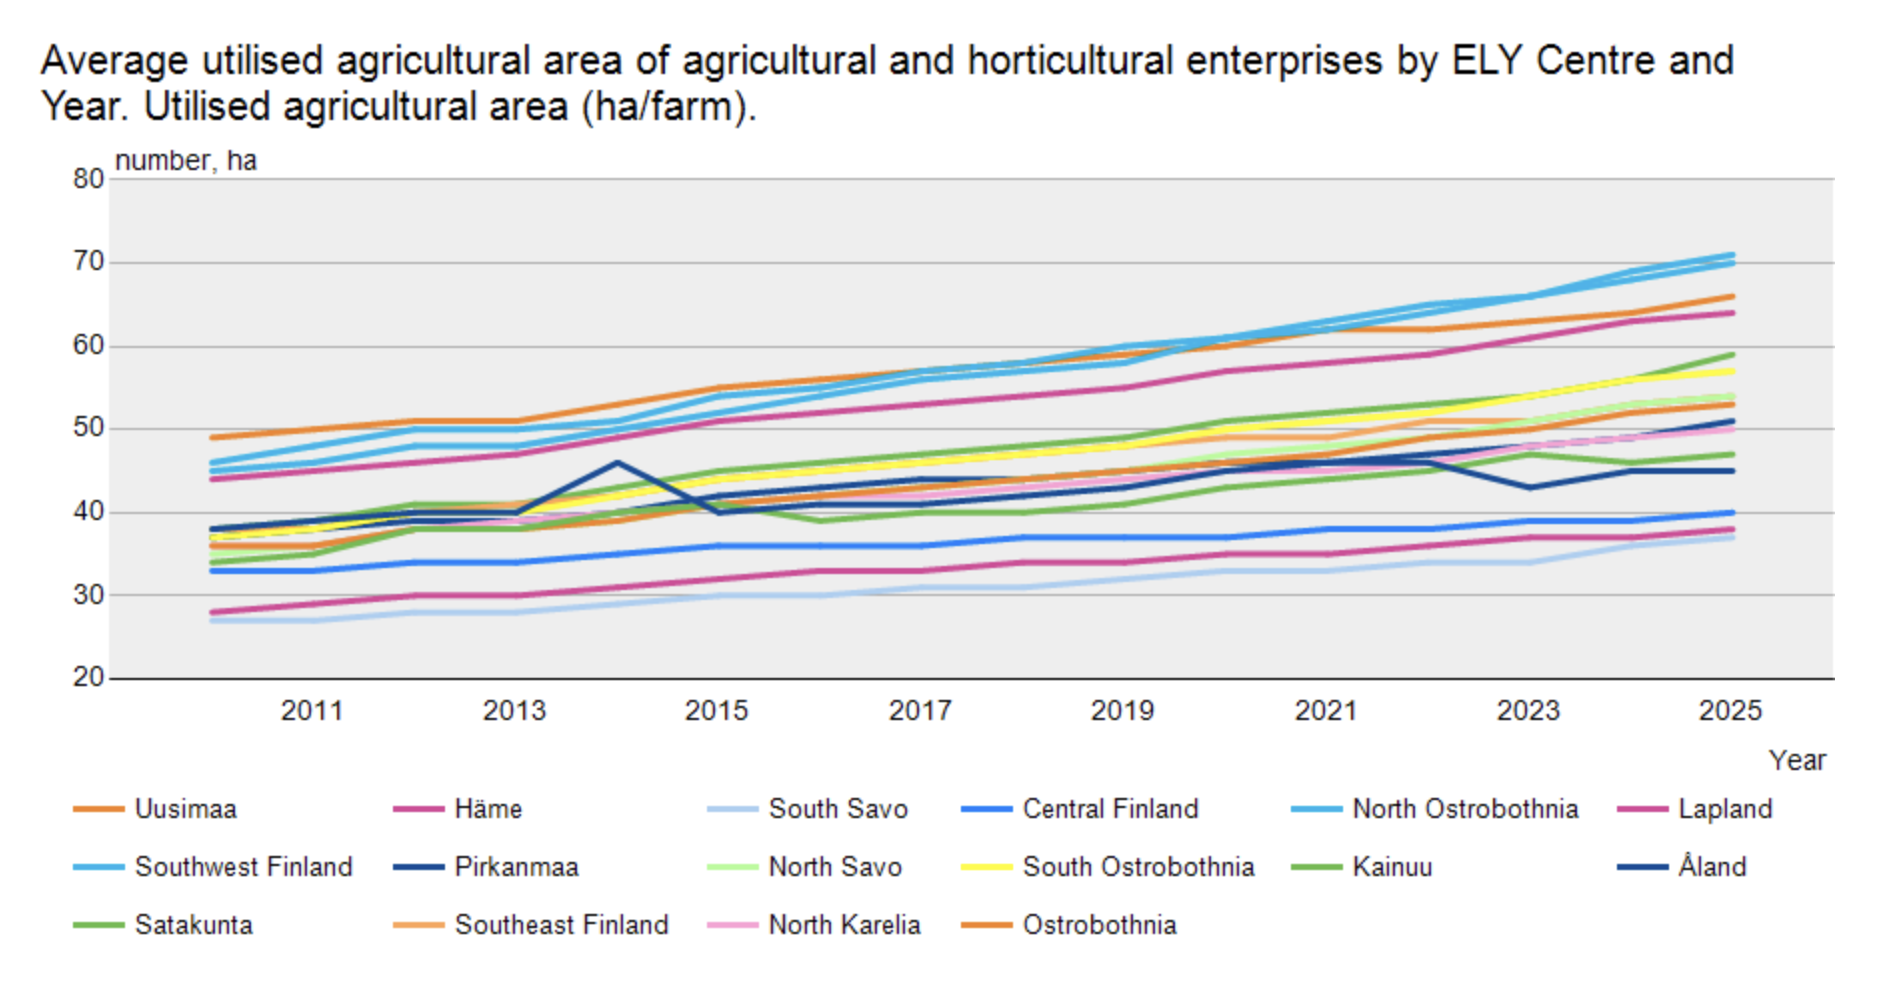

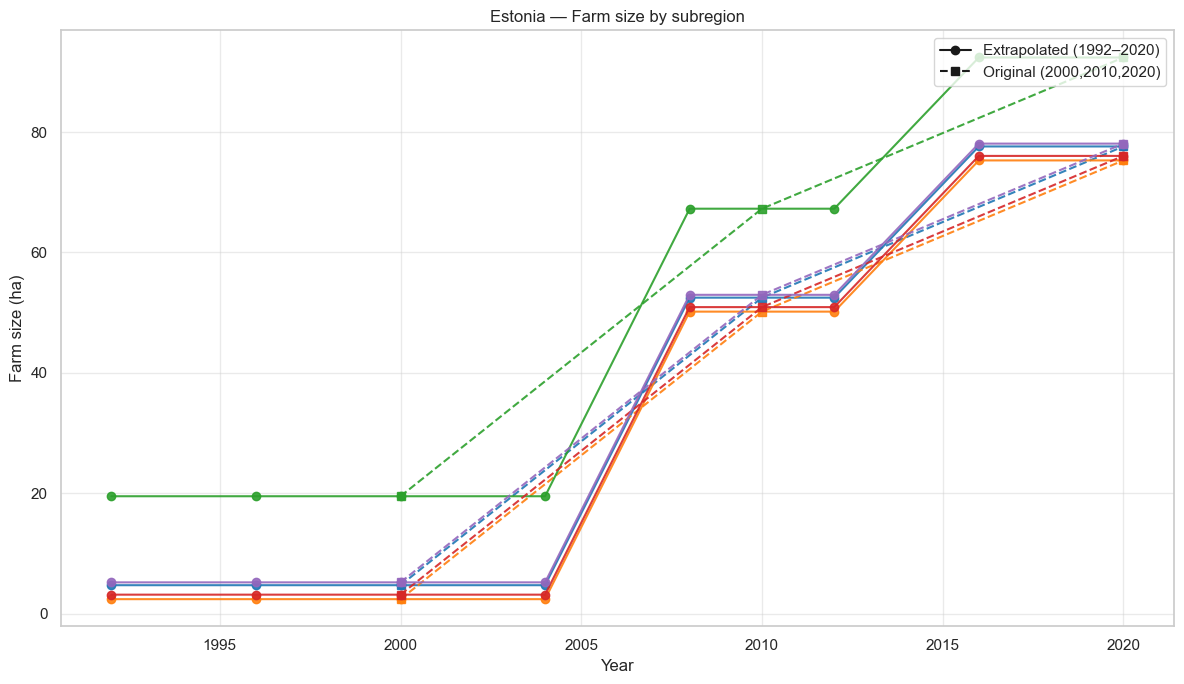

In [186]:
plotCountry('Estonia', gdf_final)

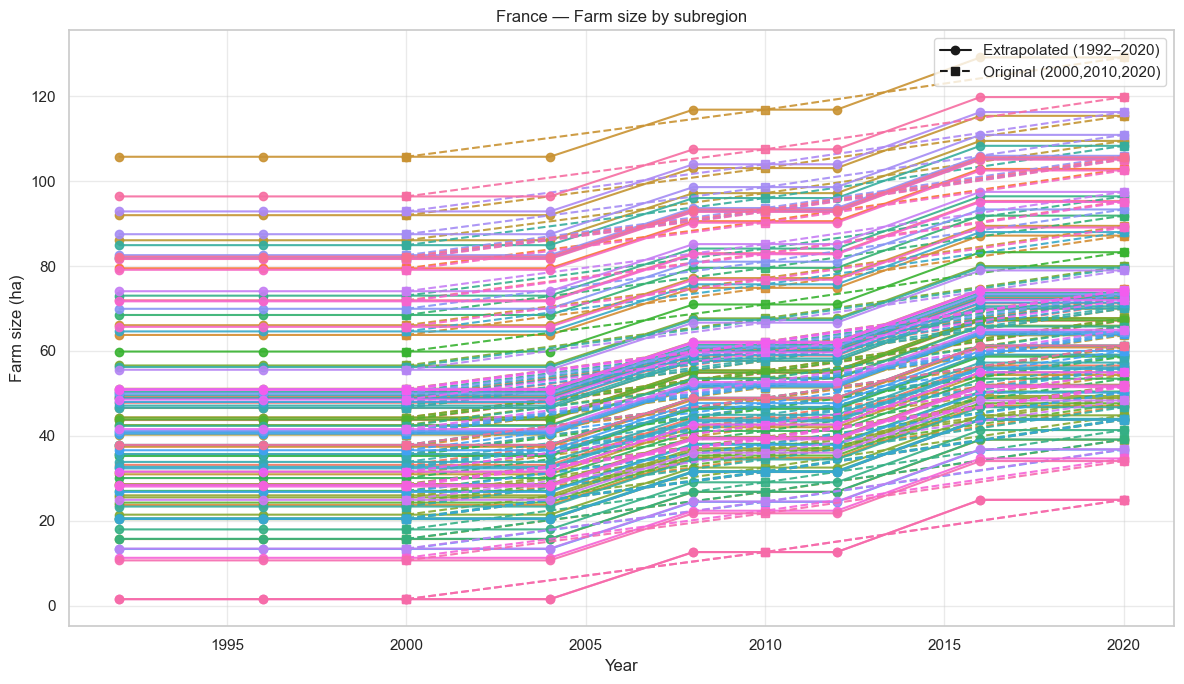

In [189]:
plotCountry('France', gdf_final)

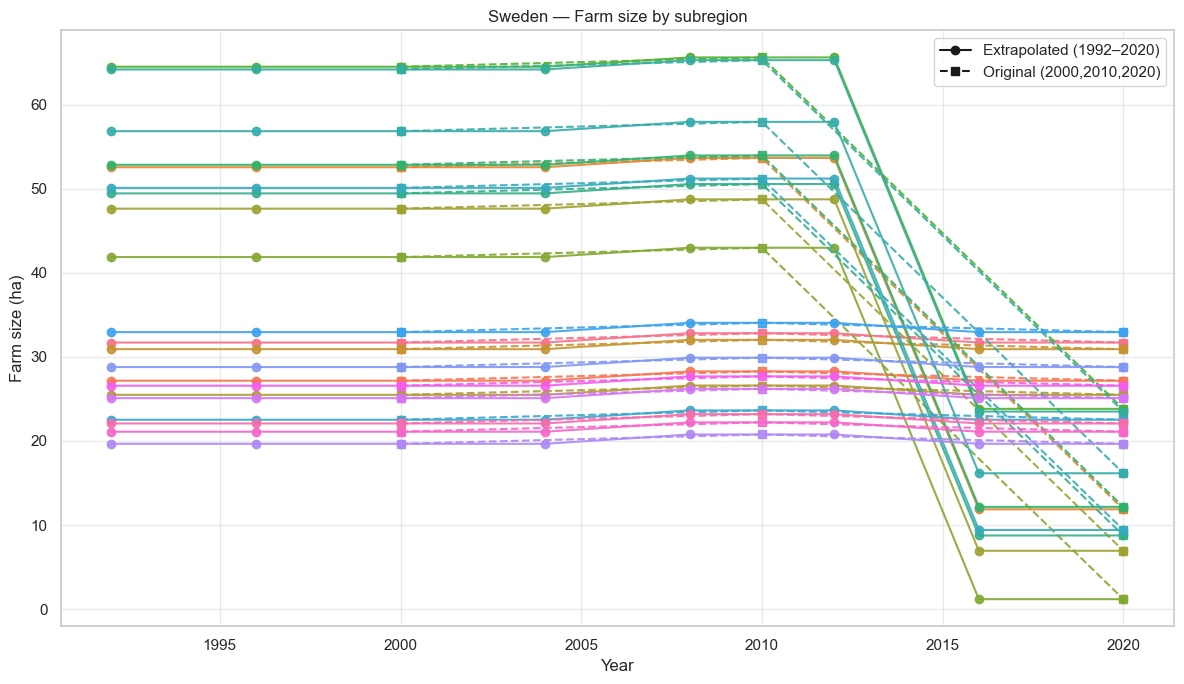

In [187]:
plotCountry('Sweden', gdf_final)

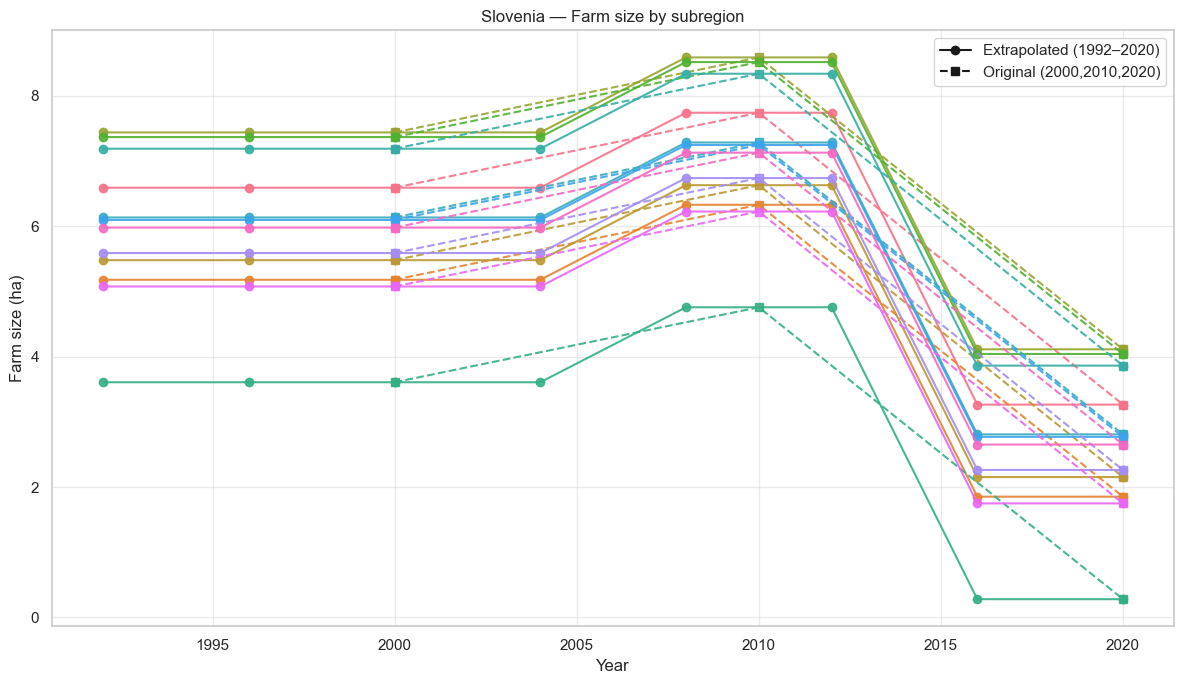

In [190]:
plotCountry('Slovenia', gdf_final)

### From Eurostat (Farm size):

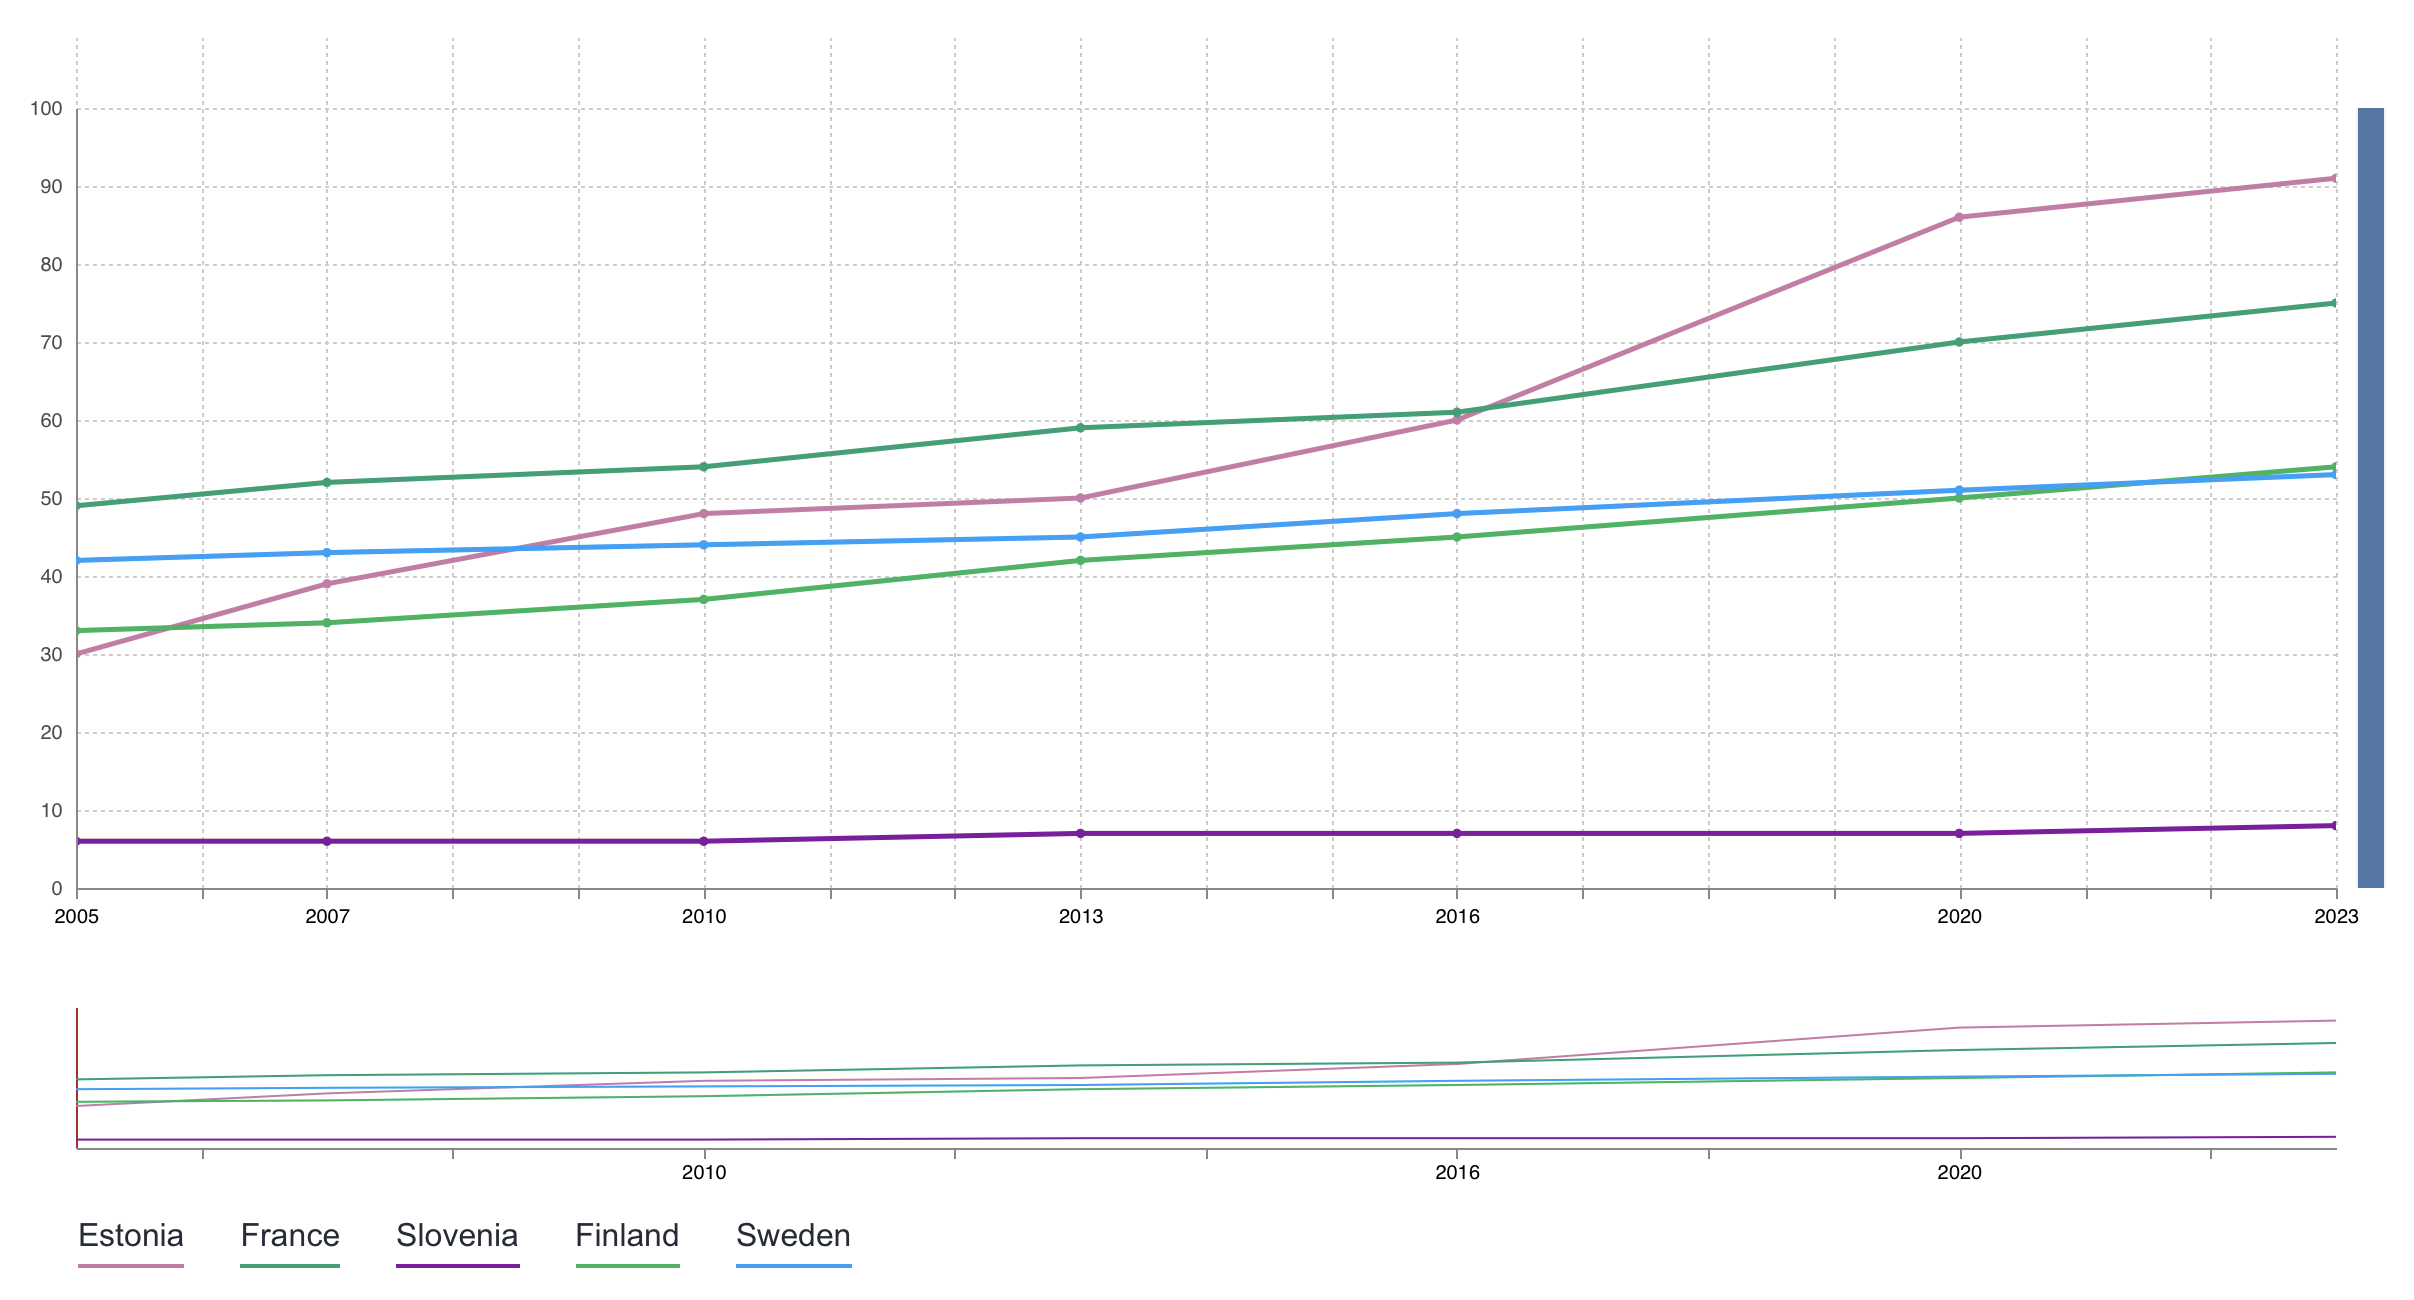

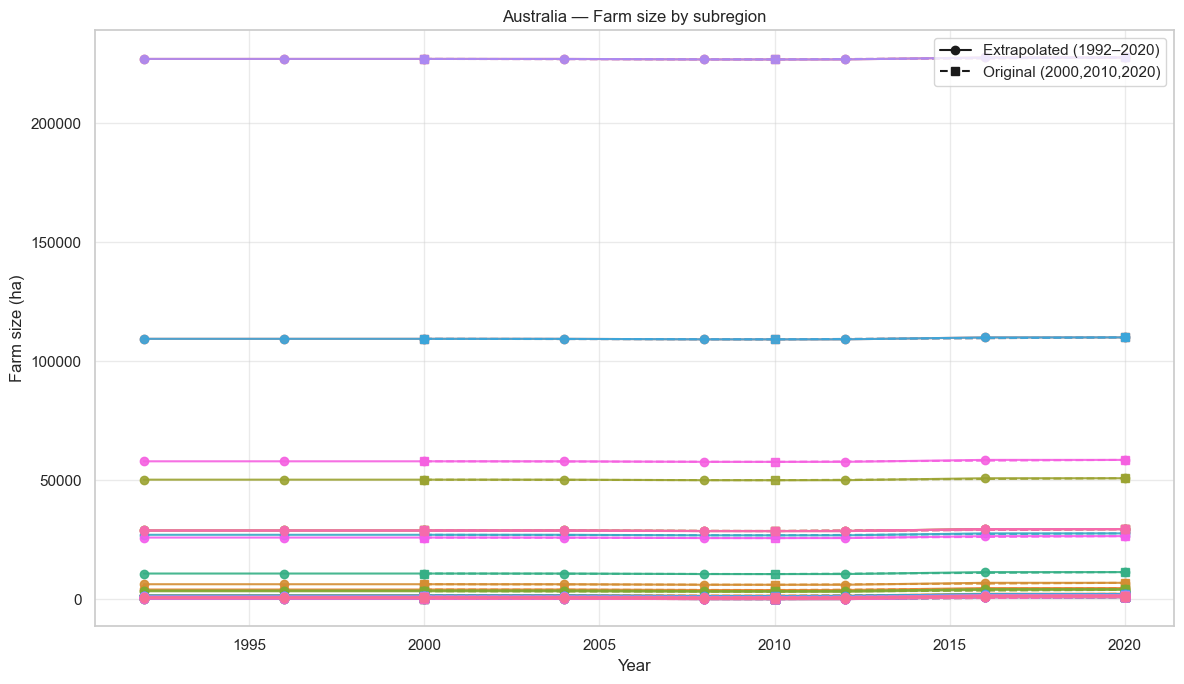

In [188]:
plotCountry('Australia', gdf_final)

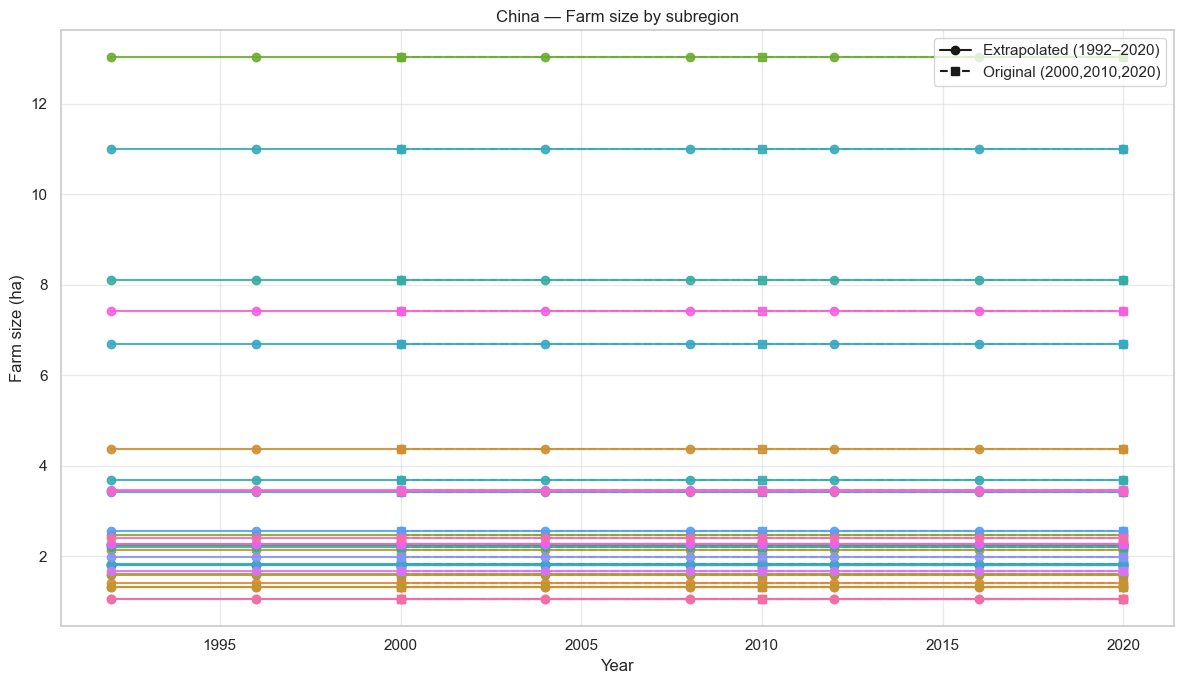

In [191]:
plotCountry('China', gdf_final)

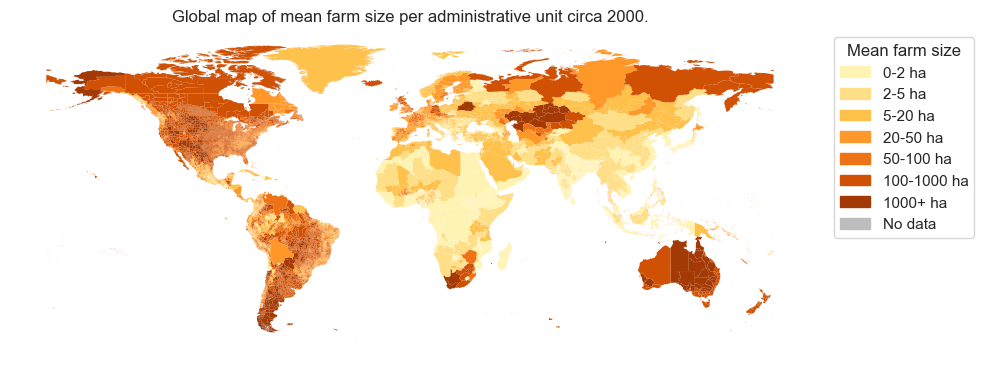

In [168]:


# bins, labels and colors
bins = [0, 2, 5, 20, 50, 100, 1000, np.inf]
labels = ['0-2 ha', '2-5 ha', '5-20 ha', '20-50 ha', '50-100 ha', '100-1000 ha', '1000+ ha']

# choose a 7-col sequential palette and convert to hex
#cmap = mpl.cm.get_cmap('YlOrBr')
cmap = mpl.colormaps.get_cmap('YlOrBr')   # or: cmap = mpl.colormaps['YlOrBr']

colors = [mpl.colors.to_hex(cmap(x)) for x in np.linspace(0.15, 0.85, len(labels))]
color_map = dict(zip(labels, colors))
nodata_color = '#bdbdbd'  # grey for no data

# make categorical column
gdf_final4326['FARMSIZE_CAT'] = pd.cut(
    gdf_final4326['FARMSIZE'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# convert to object, map to color hexes, then fill NaNs with grey
color_series = gdf_final4326['FARMSIZE_CAT'].astype(object).map(color_map).fillna(nodata_color)

# plot
fig, ax = plt.subplots(figsize=(10, 7))
gdf_final4326.plot(
    color=color_series,
    linewidth=0,
    edgecolor='white',
    ax=ax
)


# manual legend
patches = [mpatches.Patch(color=color_map[l], label=l) for l in labels] + [mpatches.Patch(color=nodata_color, label='No data')]
ax.legend(handles=patches, title='Mean farm size', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title('Global map of mean farm size per administrative unit circa 2000.')
ax.set_axis_off()

fig.tight_layout()
out = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/img/farmSize/farmSizecirca2000.png'
fig.savefig(out, dpi=300, bbox_inches="tight", transparent=True)


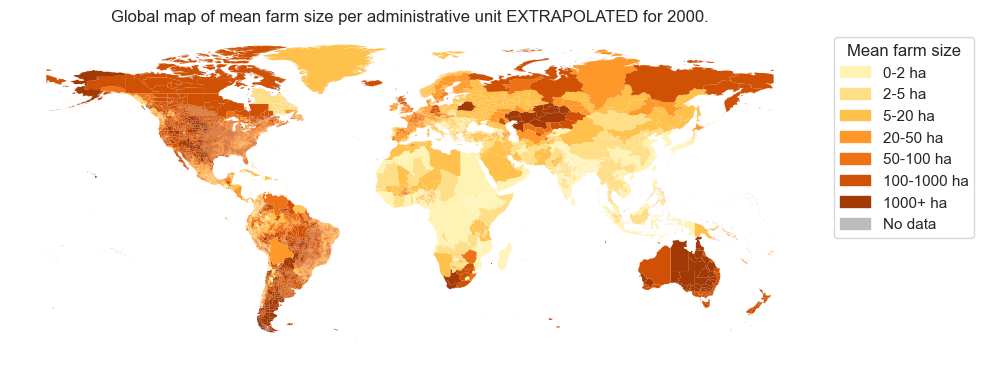

In [169]:

# make categorical column
gdf_final4326['FARMSIZE_CAT'] = pd.cut(
    gdf_final4326['EXPO_2000'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# convert to object, map to color hexes, then fill NaNs with grey
color_series = gdf_final4326['FARMSIZE_CAT'].astype(object).map(color_map).fillna(nodata_color)

# plot
fig, ax = plt.subplots(figsize=(10, 7))
gdf_final4326.plot(
    color=color_series,
    linewidth=0,
    edgecolor='white',
    ax=ax
)


# manual legend
patches = [mpatches.Patch(color=color_map[l], label=l) for l in labels] + [mpatches.Patch(color=nodata_color, label='No data')]
ax.legend(handles=patches, title='Mean farm size', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title('Global map of mean farm size per administrative unit EXTRAPOLATED for 2000.')
ax.set_axis_off()

fig.tight_layout()
out = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/img/farmSize/farmSizeEXPO_2000.png'
fig.savefig(out, dpi=300, bbox_inches="tight", transparent=True)


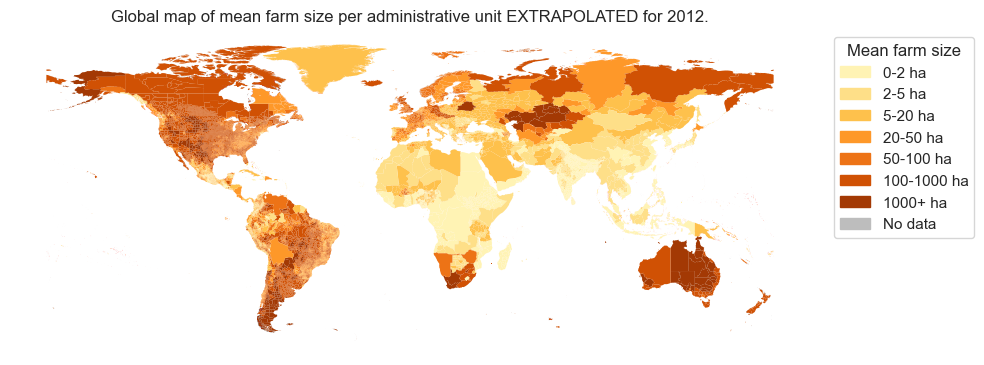

In [170]:

# make categorical column
gdf_final4326['FARMSIZE_CAT'] = pd.cut(
    gdf_final4326['EXPO_2012'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# convert to object, map to color hexes, then fill NaNs with grey
color_series = gdf_final4326['FARMSIZE_CAT'].astype(object).map(color_map).fillna(nodata_color)

# plot
fig, ax = plt.subplots(figsize=(10, 7))
gdf_final4326.plot(
    color=color_series,
    linewidth=0,
    edgecolor='white',
    ax=ax
)


# manual legend
patches = [mpatches.Patch(color=color_map[l], label=l) for l in labels] + [mpatches.Patch(color=nodata_color, label='No data')]
ax.legend(handles=patches, title='Mean farm size', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title('Global map of mean farm size per administrative unit EXTRAPOLATED for 2012.')
ax.set_axis_off()

fig.tight_layout()
out = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/img/farmSize/farmSizeEXPO_2012.png'
fig.savefig(out, dpi=300, bbox_inches="tight", transparent=True)


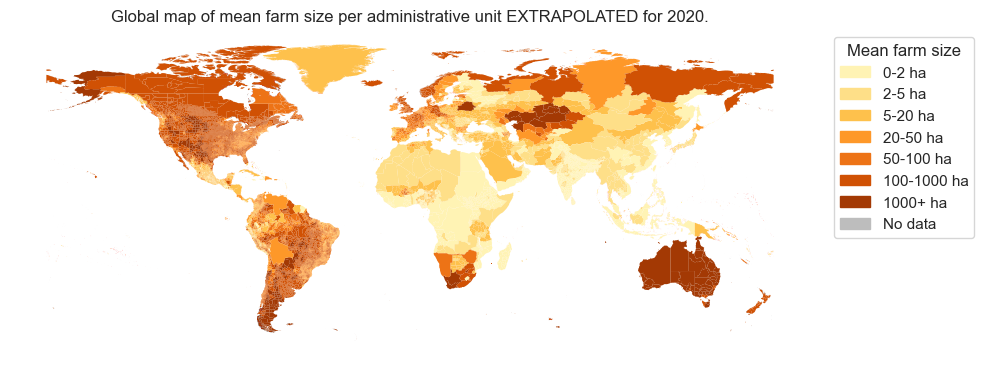

In [171]:

# make categorical column
gdf_final4326['FARMSIZE_CAT'] = pd.cut(
    gdf_final4326['EXPO_2020'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# convert to object, map to color hexes, then fill NaNs with grey
color_series = gdf_final4326['FARMSIZE_CAT'].astype(object).map(color_map).fillna(nodata_color)

# plot
fig, ax = plt.subplots(figsize=(10, 7))
gdf_final4326.plot(
    color=color_series,
    linewidth=0,
    edgecolor='white',
    ax=ax
)


# manual legend
patches = [mpatches.Patch(color=color_map[l], label=l) for l in labels] + [mpatches.Patch(color=nodata_color, label='No data')]
ax.legend(handles=patches, title='Mean farm size', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title('Global map of mean farm size per administrative unit EXTRAPOLATED for 2020.')
ax.set_axis_off()

fig.tight_layout()
out = '/Users/myliheik/Documents/myPython/sustainableFoodProduction/img/farmSize/farmSizeEXPO_2020.png'
fig.savefig(out, dpi=300, bbox_inches="tight", transparent=True)
